<a href="https://colab.research.google.com/github/gcamachoj/CF-Matematicas/blob/main/analizaor_sentimientos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Configuración Inicial y Librerías**

Esta sección se encarga de importar todas las librerías necesarias para el proyecto y configurar el dispositivo (GPU o CPU) para optimizar el entrenamiento del modelo. Se incluyen bibliotecas para manipulación de datos (pandas, numpy), el modelo BERT y su tokenizador (transformers), herramientas para PyTorch (torch.optim, torch.utils.data) y métricas de evaluación (sklearn).

In [1]:
import torch
import pandas as pd
import numpy as np
from transformers import BertTokenizer, BertForSequenceClassification # Importa el tokenizador y el modelo BERT
from torch.optim import AdamW # Importa el optimizador AdamW para el entrenamiento
from torch.utils.data import DataLoader, TensorDataset # Herramientas para manejar y cargar datos en lotes
from sklearn.model_selection import train_test_split # Función para dividir los datos en conjuntos de entrenamiento y prueba
from sklearn.metrics import classification_report, confusion_matrix # Métricas para evaluar el rendimiento del modelo

# Configuración de GPU (Asegúrate de activarla en: Entorno de ejecución > Cambiar tipo de entorno)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Detecta si hay una GPU disponible, si no, usa la CPU
print(f"Dispositivo detectado: {device}") # Imprime el dispositivo que se está utilizando

Dispositivo detectado: cuda


## **2. Montar Google Drive**

Esta celda permite conectar Google Colab con tu Google Drive, lo cual es necesario para acceder a archivos almacenados en la nube, como el dataset CSV que utilizaremos. Esto asegura que el cuaderno pueda leer y guardar datos directamente en tu espacio personal de Google Drive.

In [2]:
from google.colab import drive
drive.mount('/content/drive') # Monta tu Google Drive en el sistema de archivos de Colab

Mounted at /content/drive


After mounting your Google Drive, you can read the CSV file from its path on Drive. Please **update the `csv_file_path` variable below** to the correct path where your `Womens Clothing E-Commerce Reviews.csv` file is located in your Google Drive.

## **3. Carga y Preprocesamiento de Datos**

En esta sección se carga el archivo CSV con las reseñas de productos, se realiza una limpieza inicial de los datos y se transforman los ratings en etiquetas numéricas (0: Negativo, 1: Positivo, 2: Neutro). Finalmente, se toma una muestra de los datos y se dividen en conjuntos de entrenamiento y prueba para el modelo BERT.

In [6]:
# 1. Cargar el archivo con el nombre exacto que tienes en Colab
try:
    # Cambiamos el nombre a reviews.csv
    df = pd.read_csv('reviews.csv')
    print("Archivo 'reviews.csv' cargado exitosamente.")
except FileNotFoundError:
    print("ERROR: No se encontró el archivo. Asegúrate de subirlo a Colab con el nombre 'reviews.csv'")

# 2. Mostrar los nombres de las columnas para estar seguros
print("Columnas detectadas:", df.columns.tolist())

# 3. Limpieza: Eliminamos filas donde 'content' (el texto de la reseña) esté vacío
# Nota: Si tu CSV tiene los nombres de columna en minúsculas o diferentes, cámbialos aquí
df = df.dropna(subset=['content'])

# 4. Transformación de Ratings a etiquetas numéricas (usando la columna 'score')
def label_sentiment(rating):
    if rating <= 2: return 0  # Negativo
    if rating >= 4: return 1  # Positivo
    else: return 2            # Neutro (Rating 3)

df['label'] = df['score'].apply(label_sentiment)
df['text'] = df['content'] # Asignamos el texto de la reseña a la columna 'text'

# 5. Muestreo para agilizar el proceso en Colab
df_final = df[['text', 'label']].sample(n=min(3000, len(df)), random_state=42)

# Dividir datos (80% entrenamiento, 20% prueba)
train_text, test_text, train_labels, test_labels = train_test_split(
    df_final['text'], df_final['label'], test_size=0.2, random_state=42
)

print(f"Dataset listo: {len(train_text)} ejemplos de entrenamiento y {len(test_text)} de prueba.")

Archivo 'reviews.csv' cargado exitosamente.
Columnas detectadas: ['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'sortOrder', 'appId']
Dataset listo: 2400 ejemplos de entrenamiento y 600 de prueba.


## **4. Tokenización y Preparación para BERT**

En esta sección, se utiliza el `BertTokenizer` para convertir el texto de las reseñas en un formato numérico que BERT puede entender. Se asignan identificadores a cada palabra, se añaden tokens especiales, se maneja el relleno y el truncamiento de secuencias, y se crean las máscaras de atención. Finalmente, los datos se organizan en `DataLoaders` para facilitar el entrenamiento por lotes del modelo.

In [7]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def encode_data(texts, labels):
    encoded = tokenizer(
        texts.tolist(),
        add_special_tokens=True,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    return encoded['input_ids'], encoded['attention_mask'], torch.tensor(labels.tolist())

# Tokenizar usando las variables que generaste en la Celda 2
train_ids, train_mask, train_y = encode_data(train_text, train_labels)
test_ids, test_mask, test_y = encode_data(test_text, test_labels)

# Crear los DataLoaders
train_data = DataLoader(TensorDataset(train_ids, train_mask, train_y), batch_size=16, shuffle=True)
test_data = DataLoader(TensorDataset(test_ids, test_mask, test_y), batch_size=16)

print("Tokenización finalizada. Texto convertido a tensores para BERT.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenización finalizada. Texto convertido a tensores para BERT.


## **5. Entrenamiento del Modelo BERT**

En esta sección, se configura y entrena el modelo `BertForSequenceClassification` utilizando los datos tokenizados. Se define el número de épocas, el optimizador y se ejecuta el bucle de entrenamiento, donde el modelo aprende a clasificar el sentimiento de las reseñas. Se muestra la pérdida por lote y la pérdida promedio por época para monitorear el progreso del entrenamiento.

In [8]:
epochs = 3

# Determinar el número de etiquetas únicas de tus datos
num_labels = len(train_labels.unique())

# Inicializar el modelo BERT para clasificación
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)
model.to(device)

# Inicializar el optimizador
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)

print("Iniciando entrenamiento...\n")
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for step, batch in enumerate(train_data):
        # Mover lote a la GPU
        b_input_ids, b_input_mask, b_labels = [t.to(device) for t in batch]

        # Limpiar gradientes anteriores
        model.zero_grad()

        # Propagación hacia adelante (Forward pass)
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)

        loss = outputs.loss
        total_loss += loss.item()

        # Propagación hacia atrás (Backward pass)
        loss.backward()

        # Actualización de pesos
        optimizer.step()

        if step % 20 == 0 and not step == 0:
            print(f'Época: {epoch + 1} | Lote: {step} de {len(train_data)} | Pérdida: {loss.item():.4f}')

    avg_train_loss = total_loss / len(train_data)
    print(f"\n--- Época {epoch + 1} finalizada. Pérdida promedio: {avg_train_loss:.4f} ---\n")

print("Entrenamiento completado exitosamente.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Iniciando entrenamiento...

Época: 1 | Lote: 20 de 150 | Pérdida: 1.0894
Época: 1 | Lote: 40 de 150 | Pérdida: 0.9008
Época: 1 | Lote: 60 de 150 | Pérdida: 0.5639
Época: 1 | Lote: 80 de 150 | Pérdida: 0.7384
Época: 1 | Lote: 100 de 150 | Pérdida: 0.6574
Época: 1 | Lote: 120 de 150 | Pérdida: 0.7842
Época: 1 | Lote: 140 de 150 | Pérdida: 0.6350

--- Época 1 finalizada. Pérdida promedio: 0.7722 ---

Época: 2 | Lote: 20 de 150 | Pérdida: 0.4841
Época: 2 | Lote: 40 de 150 | Pérdida: 0.4737
Época: 2 | Lote: 60 de 150 | Pérdida: 0.4194
Época: 2 | Lote: 80 de 150 | Pérdida: 0.8772
Época: 2 | Lote: 100 de 150 | Pérdida: 0.5168
Época: 2 | Lote: 120 de 150 | Pérdida: 0.6471
Época: 2 | Lote: 140 de 150 | Pérdida: 0.5559

--- Época 2 finalizada. Pérdida promedio: 0.5509 ---

Época: 3 | Lote: 20 de 150 | Pérdida: 0.6478
Época: 3 | Lote: 40 de 150 | Pérdida: 0.4841
Época: 3 | Lote: 60 de 150 | Pérdida: 0.4530
Época: 3 | Lote: 80 de 150 | Pérdida: 0.2383
Época: 3 | Lote: 100 de 150 | Pérdida: 0.6158


## **6. Evaluación del Modelo**

En esta sección, se evalúa el rendimiento del modelo BERT entrenado utilizando el conjunto de datos de prueba. Se generan métricas clave como el reporte de clasificación (precisión, recall, F1-score) y una matriz de confusión visual. Estas herramientas permiten entender qué tan bien el modelo clasifica las reseñas en sus respectivas categorías de sentimiento (Negativo, Positivo, Neutro).

Evaluando el modelo en el set de prueba...

--- REPORTE DE RENDIMIENTO ---
              precision    recall  f1-score   support

    Negativo       0.74      0.84      0.79       224
    Positivo       0.79      0.89      0.84       271
      Neutro       0.38      0.14      0.21       105

    accuracy                           0.74       600
   macro avg       0.64      0.63      0.61       600
weighted avg       0.70      0.74      0.71       600



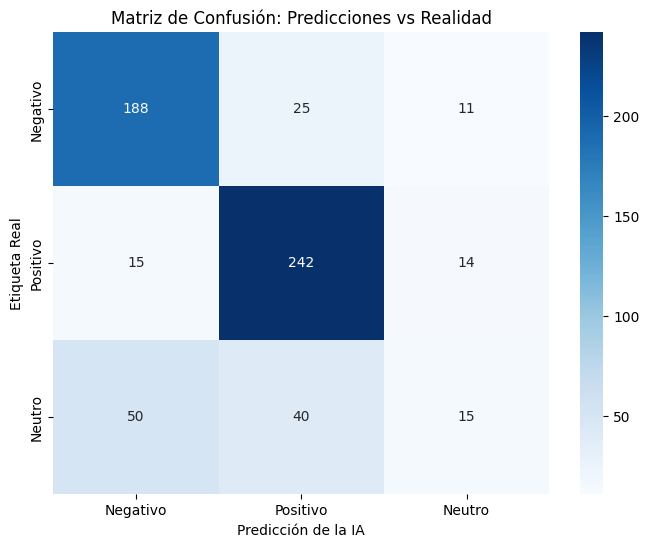

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cambiar el modelo a modo evaluación
model.eval()
predictions = []
true_labels = []

print("Evaluando el modelo en el set de prueba...")

for batch in test_data:
    b_input_ids, b_input_mask, b_labels = [t.to(device) for t in batch]

    with torch.no_grad():
        # No calculamos gradientes para ahorrar memoria y tiempo
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)

    # Obtener la predicción con mayor probabilidad (Logits)
    logits = outputs.logits.detach().cpu().numpy()
    predictions.extend(np.argmax(logits, axis=1).flatten())
    true_labels.extend(b_labels.cpu().numpy())

# 2. Generar Reporte de Clasificación (Precisión, Recall, F1)
print("\n--- REPORTE DE RENDIMIENTO ---")
target_names = ['Negativo', 'Positivo', 'Neutro']
print(classification_report(true_labels, predictions, target_names=target_names))

# 3. Generar Matriz de Confusión Visual
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Matriz de Confusión: Predicciones vs Realidad')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción de la IA')
plt.show()